In [1]:
import json
import re
from pathlib import Path
import pandas as pd


def process_instagram_messages(
    inbox_path: str,
    my_username: str,
    filter_system_messages: bool = True,
    max_gap_minutes: float = 15.0,
    max_reply_delay_minutes: float = 30.0,
    max_block_duration_minutes: float = 30.0,
):
    """Parses Instagram exported messages into input/target pairs for fine-tuning.

    Splits conversations when time gaps, reply delays, or media shares (reels/posts)
    break the contextual flow. Handles corrupted or empty JSON export files gracefully.
    """
    inbox_dir = Path(inbox_path)
    dataset = []

    max_gap_ms = max_gap_minutes * 60 * 1000
    max_reply_delay_ms = max_reply_delay_minutes * 60 * 1000
    max_block_duration_ms = max_block_duration_minutes * 60 * 1000

    REACTION_PATTERN = re.compile(
        r"Reacted\s+[\s\S]+?\s+to\s+(your|their|\w+['’]?s)\s+message",
        re.IGNORECASE,
    )
    ATTACHMENT_PATTERN = re.compile(
        r"(sent|shared)\s+(an?\s+)?(attachment|photo|video|audio|voice\s+message|file|link|sticker|a?\s*reel|post)",
        re.IGNORECASE,
    )
    EDITED_TEXT_PATTERN = re.compile(r"\s*[\(\[]edited[\)\]]\s*", re.IGNORECASE)
    
    # New patterns for call system messages and MetaAI mentions
    VIDEO_CALL_PATTERN = re.compile(
        r"^(started|ended)\s+a\s+(video\s+call|audio\s+call|call)",
        re.IGNORECASE,
    )
    META_AI_PATTERN = re.compile(r"@MetaAI\b", re.IGNORECASE)

    ATTACHMENT_KEYS = {
        "photos",
        "videos",
        "audio_files",
        "share",
        "attachments",
        "sticker",
        "clips",
    }

    for chat_folder in inbox_dir.iterdir():
        if not chat_folder.is_dir():
            continue

        chat_name = chat_folder.name
        json_files = list(chat_folder.glob("message_*.json"))
        if not json_files:
            continue

        def extract_file_index(p):
            match = re.search(r"message_(\d+)\.json$", p.name)
            return int(match.group(1)) if match else 0

        json_files.sort(key=extract_file_index, reverse=True)
        all_messages = []

        for json_file in json_files:
            file_name = json_file.name

            # Skip 0-byte empty files
            if json_file.stat().st_size == 0:
                continue

            try:
                with open(json_file, "r", encoding="utf-8") as f:
                    data = json.load(f)
            except (json.JSONDecodeError, UnicodeDecodeError):
                # Skip invalid or corrupted JSON files
                continue

            for msg in data.get("messages", []):
                sender = msg.get("sender_name")
                timestamp_ms = msg.get("timestamp_ms")
                content = msg.get("content", "")

                if not sender or not timestamp_ms:
                    continue

                # Clean encoding
                try:
                    content = content.encode("latin1").decode("utf-8")
                    sender = sender.encode("latin1").decode("utf-8")
                except (UnicodeEncodeError, UnicodeDecodeError):
                    pass

                # Detect call notifications, attachments, or system messages
                is_video_call = bool(VIDEO_CALL_PATTERN.search(content.strip()))
                is_media_or_share = (
                    any(k in msg for k in ATTACHMENT_KEYS)
                    or bool(ATTACHMENT_PATTERN.search(content))
                    or bool(REACTION_PATTERN.search(content))
                    or is_video_call
                )

                if filter_system_messages and is_media_or_share:
                    all_messages.append(
                        {
                            "sender_name": sender,
                            "content": None,
                            "timestamp_ms": timestamp_ms,
                            "file_name": file_name,
                            "is_media": True,
                            "is_edited": False,
                        }
                    )
                    continue

                # Strip @MetaAI tags from message text
                content = META_AI_PATTERN.sub("", content).strip()

                if not content:
                    continue

                is_edited = msg.get("is_edited", False) or bool(
                    EDITED_TEXT_PATTERN.search(content)
                )
                cleaned_content = EDITED_TEXT_PATTERN.sub("", content).strip()

                if not cleaned_content:
                    continue

                all_messages.append(
                    {
                        "sender_name": sender,
                        "content": cleaned_content,
                        "timestamp_ms": timestamp_ms,
                        "file_name": file_name,
                        "is_media": False,
                        "is_edited": is_edited,
                    }
                )

        all_messages.sort(key=lambda x: x["timestamp_ms"])

        current_input = []
        current_target = []
        source_file = None
        last_msg_time = None

        def commit_pair():
            nonlocal current_input, current_target, source_file
            if current_input and current_target and source_file:
                reply_delay_ms = (
                    current_target[0]["timestamp_ms"] - current_input[-1]["timestamp_ms"]
                )
                duration_input_ms = (
                    current_input[-1]["timestamp_ms"] - current_input[0]["timestamp_ms"]
                )
                duration_target_ms = (
                    current_target[-1]["timestamp_ms"] - current_target[0]["timestamp_ms"]
                )

                if reply_delay_ms <= max_reply_delay_ms:
                    dataset.append(
                        {
                            "conversation": f"{chat_name}/{source_file}",
                            "input": "\n".join(m["content"] for m in current_input),
                            "target": "\n".join(
                                m["content"] for m in current_target
                            ),
                            "timestamp_input": current_input[0]["timestamp_ms"],
                            "timestamp_target": current_target[0]["timestamp_ms"],
                            "count_input": len(current_input),
                            "count_target": len(current_target),
                            "duration_input_ms": duration_input_ms,
                            "duration_target_ms": duration_target_ms,
                            "reply_delay_ms": reply_delay_ms,
                        }
                    )

            current_input = []
            current_target = []

        for msg in all_messages:
            if msg.get("is_media"):
                commit_pair()
                last_msg_time = None
                continue

            sender = msg["sender_name"]
            msg_time = msg["timestamp_ms"]

            if last_msg_time is not None:
                if (msg_time - last_msg_time) > max_gap_ms:
                    commit_pair()

            last_msg_time = msg_time

            if sender != my_username:
                if current_target:
                    commit_pair()

                if current_input:
                    block_duration = msg_time - current_input[0]["timestamp_ms"]
                    if block_duration > max_block_duration_ms:
                        commit_pair()

                if (
                    current_input
                    and current_input[-1]["sender_name"] == sender
                    and (msg["is_edited"] or msg_time == current_input[-1]["timestamp_ms"])
                ):
                    current_input[-1] = msg
                else:
                    current_input.append(msg)

                source_file = msg["file_name"]
            else:
                if current_input:
                    if current_target:
                        block_duration = msg_time - current_target[0]["timestamp_ms"]
                        if block_duration > max_block_duration_ms:
                            commit_pair()

                    if (
                        current_target
                        and current_target[-1]["sender_name"] == sender
                        and (msg["is_edited"] or msg_time == current_target[-1]["timestamp_ms"])
                    ):
                        current_target[-1] = msg
                    else:
                        current_target.append(msg)

        commit_pair()

    return dataset

In [7]:
from io import StringIO
import pandas as pd

data = process_instagram_messages(
    inbox_path="dataset/datafolders",
    my_username="Nox",
    filter_system_messages=True,
    max_gap_minutes=2.0,
    max_reply_delay_minutes=10.0,
    max_block_duration_minutes=2.0,
)
dataframe = pd.DataFrame(data)

# Convert duration and delay metrics to minutes and days
dataframe["duration_input_min"] = dataframe["duration_input_ms"] / 60000
dataframe["duration_target_min"] = dataframe["duration_target_ms"] / 60000
dataframe["reply_delay_min"] = dataframe["reply_delay_ms"] / 60000
dataframe["reply_delay_days"] = dataframe["reply_delay_ms"] / (
    60000 * 60 * 24
)

# Filter by target character length
dataframe = dataframe[(dataframe["target"].str.len() > 50) & (dataframe["target"].str.len() < 400)]

# =========================================================
# TIMESTAMP CONVERSION & AGE FILTERING
# =========================================================
# Assuming your timestamp column in 'data' is named 'timestamp_ms'
# (Change 'timestamp_ms' below if your dict uses 'timestamp' or 'created_at')
TIMESTAMP_COL = "timestamp_target"

if TIMESTAMP_COL in dataframe.columns:
    # Convert milliseconds to datetime objects
    dataframe["datetime"] = pd.to_datetime(dataframe[TIMESTAMP_COL], unit="ms")

    # Choose cutoff: 365 days (1 year) or 730 days (2 years)
    cutoff_date = pd.Timestamp.now() - pd.Timedelta(days=730)

    # Alternatively, filter relative to the dataset's newest message instead of today:
    # cutoff_date = dataframe["datetime"].max() - pd.Timedelta(days=365)

    dataframe = dataframe[dataframe["datetime"] >= cutoff_date]

dataframe.shape

(1828, 15)

In [109]:
# Filter and display all matching messages

dataframe.shape

(4346, 14)

In [83]:
print(dataframe["input"].iloc[19733])

Go ahead


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def analyze_message_char_length(
    df: pd.DataFrame,
    column_name: str,
) -> tuple[pd.DataFrame, dict]:
    """Calculates character lengths for a specified message column, prints key length

    percentiles (including p10 and p25), and plots the distribution.
    """
    new_col_name = f"{column_name}_char_len"

    # 1. Calculate Character Lengths
    df[new_col_name] = df[column_name].apply(lambda x: len(str(x)))
    lengths = df[new_col_name]

    # 2. Calculate Summary Statistics & Percentiles
    mean_len = lengths.mean()
    median_len = lengths.median()
    p10 = lengths.quantile(0.10)
    p25 = lengths.quantile(0.25)
    p90 = lengths.quantile(0.90)
    p95 = lengths.quantile(0.95)
    p99 = lengths.quantile(0.99)
    max_len = lengths.max()

    percentiles = {
        "mean": mean_len,
        "median": median_len,
        "p10": p10,
        "p25": p25,
        "p90": p90,
        "p95": p95,
        "p99": p99,
        "max": max_len,
    }

    # Print Summary Output
    print(f"=== {column_name} Character Length Analysis ===")
    print(f"Mean Length:     {mean_len:.2f} chars")
    print(f"Median Length:   {median_len:.2f} chars")
    print(f"10th Percentile: {p10:.2f} chars (Covers 10% of dataset)")
    print(f"25th Percentile: {p25:.2f} chars (Covers 25% of dataset)")
    print(f"90th Percentile: {p90:.2f} chars (Covers 90% of dataset)")
    print(f"95th Percentile: {p95:.2f} chars (Covers 95% of dataset)")
    print(f"99th Percentile: {p99:.2f} chars (Covers 99% of dataset)")
    print(f"Max Length:      {max_len} chars")
    print("=========================================\n")

    # 3. Plot Distribution
    plt.figure(figsize=(10, 5))
    sns.histplot(lengths, kde=True, bins=30, color="teal")

    # Add vertical indicator lines for key metrics
    plt.axvline(
        p10,
        color="purple",
        linestyle=":",
        label=f"10th Pct ({p10:.1f})",
    )
    plt.axvline(
        p25,
        color="purple",
        linestyle="--",
        label=f"25th Pct ({p25:.1f})",
    )
    plt.axvline(
        mean_len,
        color="red",
        linestyle="--",
        label=f"Mean ({mean_len:.1f})",
    )
    plt.axvline(
        p95,
        color="green",
        linestyle="--",
        label=f"95th Pct ({p95:.1f})",
    )
    plt.axvline(
        p99,
        color="orange",
        linestyle="--",
        label=f"99th Pct ({p99:.1f})",
    )

    plt.title(f"Distribution of {column_name} (Character Counts)")
    plt.xlabel("Number of Characters")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return df, percentiles

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def analyze_column_length(
    df: pd.DataFrame,
    column_name: str,
    tokenizer=None,
    count_type: str = "token",  # 'token' or 'word'
) -> tuple[pd.DataFrame, dict]:
    """Calculates word or token lengths for a specified column, prints key length

    percentiles (including p10 and p25), and plots the distribution.
    """
    new_col_name = (
        f"{column_name}_token_len"
        if count_type == "token"
        else f"{column_name}_word_len"
    )

    # 1. Calculate Lengths
    if count_type == "token":
        if tokenizer is None:
            raise ValueError(
                "A tokenizer must be provided when count_type='token'."
            )
        df[new_col_name] = df[column_name].apply(
            lambda x: len(tokenizer.encode(str(x), truncation=False))
        )
    else:
        df[new_col_name] = df[column_name].apply(
            lambda x: len(str(x).split())
        )

    lengths = df[new_col_name]

    # 2. Calculate Summary Statistics & Percentiles
    mean_len = lengths.mean()
    median_len = lengths.median()
    p10 = lengths.quantile(0.10)
    p25 = lengths.quantile(0.25)
    p90 = lengths.quantile(0.90)
    p95 = lengths.quantile(0.95)
    p99 = lengths.quantile(0.99)
    max_len = lengths.max()

    percentiles = {
        "mean": mean_len,
        "median": median_len,
        "p10": p10,
        "p25": p25,
        "p90": p90,
        "p95": p95,
        "p99": p99,
        "max": max_len,
    }

    # Print Summary Output
    print(f"=== {column_name} Length Analysis ({count_type}s) ===")
    print(f"Mean Length:     {mean_len:.2f}")
    print(f"Median Length:   {median_len:.2f}")
    print(f"10th Percentile: {p10:.2f} (Covers 10% of dataset)")
    print(f"25th Percentile: {p25:.2f} (Covers 25% of dataset)")
    print(f"90th Percentile: {p90:.2f} (Covers 90% of dataset)")
    print(f"95th Percentile: {p95:.2f} (Covers 95% of dataset)")
    print(f"99th Percentile: {p99:.2f} (Covers 99% of dataset)")
    print(f"Max Length:      {max_len}")
    print("=========================================\n")

    # 3. Plot Distribution
    plt.figure(figsize=(10, 5))
    sns.histplot(lengths, kde=True, bins=30, color="skyblue")

    # Add vertical indicator lines for key metrics
    plt.axvline(
        p10,
        color="purple",
        linestyle=":",
        label=f"10th Pct ({p10:.1f})",
    )
    plt.axvline(
        p25,
        color="purple",
        linestyle="--",
        label=f"25th Pct ({p25:.1f})",
    )
    plt.axvline(
        mean_len,
        color="red",
        linestyle="--",
        label=f"Mean ({mean_len:.1f})",
    )
    plt.axvline(
        p95,
        color="green",
        linestyle="--",
        label=f"95th Pct ({p95:.1f})",
    )
    plt.axvline(
        p99,
        color="orange",
        linestyle="--",
        label=f"99th Pct ({p99:.1f})",
    )

    plt.title(f"Distribution of {column_name} ({count_type.title()} Counts)")
    plt.xlabel(f"Number of {count_type.title()}s")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return df, percentiles

=== target Length Analysis (tokens) ===
Mean Length:     13.30
Median Length:   9.00
10th Percentile: 2.00 (Covers 10% of dataset)
25th Percentile: 4.00 (Covers 25% of dataset)
90th Percentile: 29.00 (Covers 90% of dataset)
95th Percentile: 39.00 (Covers 95% of dataset)
99th Percentile: 76.00 (Covers 99% of dataset)
Max Length:      1014



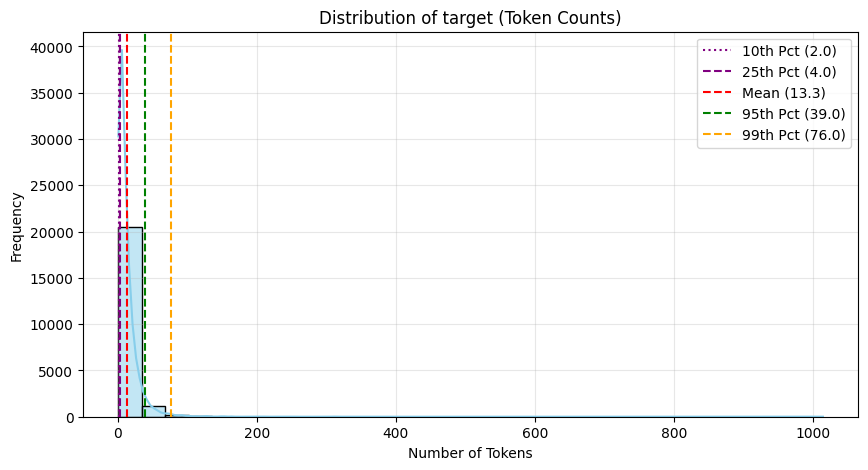

In [22]:
from transformers import AutoTokenizer

# Load Qwen 3.5 2B tokenizer directly
tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen3.5-2B", trust_remote_code=True
)

# Run the length analysis with Qwen 3.5 2B
df = analyze_column_length(
    df=dataframe,
    column_name="target",
    tokenizer=tokenizer,
    count_type="token",
)

=== target Length Analysis (words) ===
Mean Length:     9.73
Median Length:   6.00
10th Percentile: 1.00 (Covers 10% of dataset)
25th Percentile: 3.00 (Covers 25% of dataset)
90th Percentile: 21.00 (Covers 90% of dataset)
95th Percentile: 30.00 (Covers 95% of dataset)
99th Percentile: 57.72 (Covers 99% of dataset)
Max Length:      770



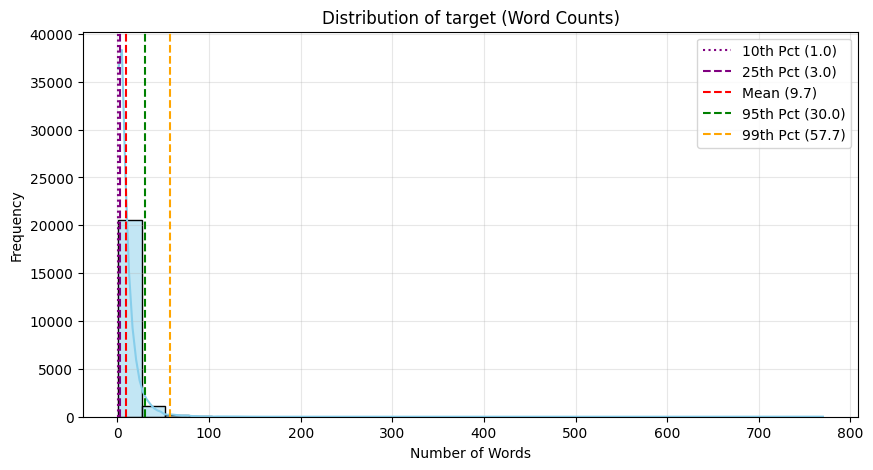

In [23]:
# Analyzes raw space-separated word length
df = analyze_column_length(
    df=dataframe,
    column_name="target",
    count_type="word",
)

In [24]:
df, char_stats = analyze_message_char_length(dataframe, column_name="target")

NameError: name 'analyze_message_char_length' is not defined

In [23]:
from collections import Counter

def get_word_counts_df(df: pd.DataFrame, column_name: str = "input"):
    full_text = " ".join(df[column_name].dropna().astype(str)).lower()

    # Extract words ignoring punctuation/newlines
    words = re.findall(r"\b[\w']+\b", full_text)

    # Count frequencies
    counts = Counter(words)

    # Create DataFrame
    word_df = pd.DataFrame(counts.items(), columns=["word", "count"])
    word_df = word_df.sort_values(by="count", ascending=False).reset_index(
        drop=True
    )

    return word_df


# --- Usage ---
word_df = get_word_counts_df(dataframe, column_name="target")
print(word_df.head(20))

# Export to CSV if needed:
word_df.to_csv("target_word_counts_truncated.csv", index=False)

    word  count
0    the  10556
1      i   8813
2     to   6965
3      a   5867
4    you   5185
5    and   5104
6     is   4649
7     it   4430
8     of   3564
9   that   3334
10    in   3171
11   for   2378
12   its   2333
13  this   2153
14   not   1996
15  like   1957
16    my   1933
17  what   1921
18  with   1900
19    me   1883


In [8]:
import json
from pathlib import Path
import pandas as pd


def prepare_qwen_dataset(
    df: pd.DataFrame,
    output_path: str = "data/train_data.jsonl",
    system_prompt: str = "You are Nox. Answer in your personal style.",
):
    """Converts input/target DataFrame into JSONL conversational format for Qwen fine-tuning."""
    # Unpack tuple if a tuple containing a DataFrame was passed
    if isinstance(df, tuple):
        df = df[0]

    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Expected a pandas DataFrame or tuple containing one, got {type(df)}")

    records = []

    for _, row in df.iterrows():
        record = {
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": row["input"]},
                {"role": "assistant", "content": row["target"]},
            ]
        }
        records.append(record)

    # Ensure target directory exists before writing
    output_file = Path(output_path)
    output_file.parent.mkdir(parents=True, exist_ok=True)

    with open(output_file, "w", encoding="utf-8") as f:
        for entry in records:
            f.write(json.dumps(entry, ensure_ascii=False) + "\n")

    print(f"Saved {len(records)} training samples to {output_path}")


# Check variable before passing
if isinstance(dataframe, tuple):
    dataframe = dataframe[0]

system_prompt = """You are Nox, a friend texting on Discord/IG direct messages.

Rules:
- Tone: Casual, dry humor. Never sound like an AI assistant.
- Format: Use lowercase with some ALL CAPS for shock/excitement or to express a bubbly personality, trying to match the User. Omit trailing periods.
- Mechanics: Keep responses short most of the time. occasionally when it gets to talking about information use long paragraphs to explain in a nerdy way.
- Behavior: Reply directly without repeating what was said. If indifferent, keep it brief (e.g., "idk honestly", "idc")."""

prepare_qwen_dataset(dataframe, "dataset/train_dataV2.65.jsonl", system_prompt=system_prompt)

Saved 1828 training samples to dataset/train_dataV2.65.jsonl


In [3]:
import os

os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"

import torch
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from trl import SFTConfig, SFTTrainer

MODEL_PATH = "./model/Qwen3.5-2B/snapshots/15852e8c16360a2fea060d615a32b45270f8a8fc"

# 1. Quantization Setup
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# 2. Load Tokenizer & Text Model Directly
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    trust_remote_code=True,
    padding_side="right",
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    attn_implementation="sdpa",
    device_map="auto",
    trust_remote_code=True,
)

model = prepare_model_for_kbit_training(model)

# 3. LoRA Setup
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, peft_config)

# 4. Load Dataset
dataset = load_dataset("json", data_files={"train": "./dataset/train_data.jsonl"})["train"]


# 5. Text-Only Collator
def collate_fn(batch):
    texts = [
        tokenizer.apply_chat_template(
            example["messages"], tokenize=False, add_generation_prompt=False
        )
        for example in batch
    ]

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    )

    labels = inputs["input_ids"].clone()
    labels[labels == tokenizer.pad_token_id] = -100
    inputs["labels"] = labels

    return inputs


# 6. Training Configurations
sft_config = SFTConfig(
    output_dir="./qwen3_5_finetuned",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    logging_steps=10,
    max_length=128,
    num_train_epochs=2,
    dataloader_num_workers=2,  # Multi-threaded worker processes
    dataloader_persistent_workers=True,  # Prevents worker recreation between epochs
    dataloader_pin_memory=True,
    bf16=True,
    fp16=False,
    save_strategy="epoch",
    optim="adamw_torch_fused",
    remove_unused_columns=False,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    data_collator=collate_fn,
    args=sft_config,
)

if __name__ == "__main__":
    print("Starting training execution...")
    trainer.train()

    trainer.model.save_pretrained("./qwen3_5_finetuned")
    tokenizer.save_pretrained("./qwen3_5_finetuned")
    print("Model adapters and tokenizer saved successfully.")

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.


Starting training execution...


ValueError: persistent_workers option needs num_workers > 0

In [25]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()